In [8]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path('/kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026')
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from src.model import TextCNN
from src.train import train_model
from src.evaluate import evaluate_model, get_predictions, plot_confusion_matrix
from src.dataset import build_vocabulary, load_glove, create_dataloaders

RESULTS_DIR = Path('/kaggle/working/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


In [9]:
processed_path = PROJECT_ROOT / 'data' / 'processed' / 'wellfake_processed.csv'
df = pd.read_csv(processed_path)
df['title'] = df['title'].fillna('')
df['text']  = df['text'].fillna('')

print(f'Cargado desde cache: {processed_path}')
print(f'Forma: {df.shape}')

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

word2idx   = build_vocabulary(train_df['text_combined'].tolist(), max_vocab=20000)
idx2word   = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)

train_loader, val_loader, test_loader = create_dataloaders(
    (train_df['text_combined'].tolist(), train_df['label'].tolist()),
    (val_df['text_combined'].tolist(),   val_df['label'].tolist()),
    (test_df['text_combined'].tolist(),  test_df['label'].tolist()),
    word2idx, batch_size=64, max_len=200)

print(f'Vocabulario: {VOCAB_SIZE:,} tokens')

Cargado desde cache: /kaggle/input/datasets/gmschen/modelado-predictivo-carpeta/ModeladoPredictivo2026/data/processed/wellfake_processed.csv
Forma: (61394, 6)
DataLoaders creados:
  Entrenamiento: 49,115 muestras -> 768 batches
  Validacion:    6,139 muestras -> 96 batches
  Prueba:        6,140 muestras -> 96 batches
  Batch size: 64 | Max len: 200
Vocabulario: 20,002 tokens


In [10]:
GLOVE_PATH_100 = PROJECT_ROOT / 'data' / 'embeddings' / 'glove.6B.100d.txt'
emb_matrix = load_glove(str(GLOVE_PATH_100), word2idx, 100) if GLOVE_PATH_100.exists() else None

BEST_CONFIG = {'embed_dim': 100, 'num_filters': 256, 'kernel_sizes': [3, 4, 5], 'dropout': 0.5, 'lr': 0.001}

torch.manual_seed(42)
model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=BEST_CONFIG['embed_dim'],
    num_filters=BEST_CONFIG['num_filters'],
    kernel_sizes=BEST_CONFIG['kernel_sizes'],
    dropout=BEST_CONFIG['dropout'],
    pretrained_embeddings=emb_matrix,
).to(device)

opt  = torch.optim.Adam(model.parameters(), lr=BEST_CONFIG['lr'])
crit = nn.BCEWithLogitsLoss()
hist = train_model(model, train_loader, val_loader, opt, crit, device, num_epochs=15, patience=3)
print('\nModelo (AG evolucionado) entrenado.')

GloVe cargado: 19,520 / 20,002 palabras encontradas (97.6% de cobertura)
Epoch 01/15 | Train Loss: 0.1902  Train F1: 0.9105 | Val Loss: 0.1062  Val F1: 0.9515
Epoch 02/15 | Train Loss: 0.0829  Train F1: 0.9651 | Val Loss: 0.0921  Val F1: 0.9578
Epoch 03/15 | Train Loss: 0.0457  Train F1: 0.9815 | Val Loss: 0.0960  Val F1: 0.9578
Epoch 04/15 | Train Loss: 0.0227  Train F1: 0.9910 | Val Loss: 0.1140  Val F1: 0.9600
Epoch 05/15 | Train Loss: 0.0127  Train F1: 0.9950 | Val Loss: 0.1346  Val F1: 0.9569
Epoch 06/15 | Train Loss: 0.0086  Train F1: 0.9971 | Val Loss: 0.1518  Val F1: 0.9571
Epoch 07/15 | Train Loss: 0.0059  Train F1: 0.9982 | Val Loss: 0.1772  Val F1: 0.9514

Early stopping en epoca 7. Mejor Val F1: 0.9600

Modelo (AG evolucionado) entrenado.


In [11]:
test_metrics = evaluate_model(model, test_loader, crit, device)

# Resultados manuales del Reto 5
manual_csv = PROJECT_ROOT / "results" / 'experiments.csv'
if manual_csv.exists():
    exp_df = pd.read_csv(manual_csv)
    exp_df['val_f1_num'] = exp_df['val_f1'].astype(float)
    best_manual = exp_df.loc[exp_df['val_f1_num'].idxmax()]
    manual_f1  = float(best_manual['test_f1'])
    manual_acc = float(best_manual['test_accuracy'])
else:
    manual_f1, manual_acc = 0.9617, 0.9658  # valores del Reto 5 (filters_350)
    print('experiments.csv no encontrado en esta sesion; usando valores guardados del Reto 5.')

# Tabla final con TODOS los modelos del curso
final_table = pd.DataFrame({
    'Modelo': [
        'TF-IDF + Log. Regression (Reto 2)',
        'TF-IDF + SVM (Reto 2)',
        'TF-IDF + Naive Bayes (Reto 2)',
        'TextCNN Random (Reto 4)',
        'TextCNN GloVe (Reto 4)',
        'TextCNN Manual Best (Reto 5)',
        'TextCNN AG Evolucionado (Reto 6)',
        'BERT fine-tuned (referencia literatura)',
    ],
    'Accuracy': ['0.9717', '0.9630', '0.9070', '0.9617', '0.9596', f'{manual_acc:.4f}',
                 f"{test_metrics['accuracy']:.4f}", '~0.987'],
    'F1-Score': ['0.9717', '0.9630', '0.9070', '0.9560', '0.9549', f'{manual_f1:.4f}',
                 f"{test_metrics['f1']:.4f}", '~0.988'],
})

print('=' * 70)
print('    TABLA COMPARATIVA FINAL — TODOS LOS MODELOS DEL CURSO')
print('=' * 70)
print(final_table.to_string(index=False))
print('=' * 70)

    TABLA COMPARATIVA FINAL — TODOS LOS MODELOS DEL CURSO
                                 Modelo Accuracy F1-Score
      TF-IDF + Log. Regression (Reto 2)   0.9717   0.9717
                  TF-IDF + SVM (Reto 2)   0.9630   0.9630
          TF-IDF + Naive Bayes (Reto 2)   0.9070   0.9070
                TextCNN Random (Reto 4)   0.9617   0.9560
                 TextCNN GloVe (Reto 4)   0.9596   0.9549
           TextCNN Manual Best (Reto 5)   0.9658   0.9617
       TextCNN AG Evolucionado (Reto 6)   0.9671   0.9630
BERT fine-tuned (referencia literatura)   ~0.987   ~0.988


Ejecutando t-SNE


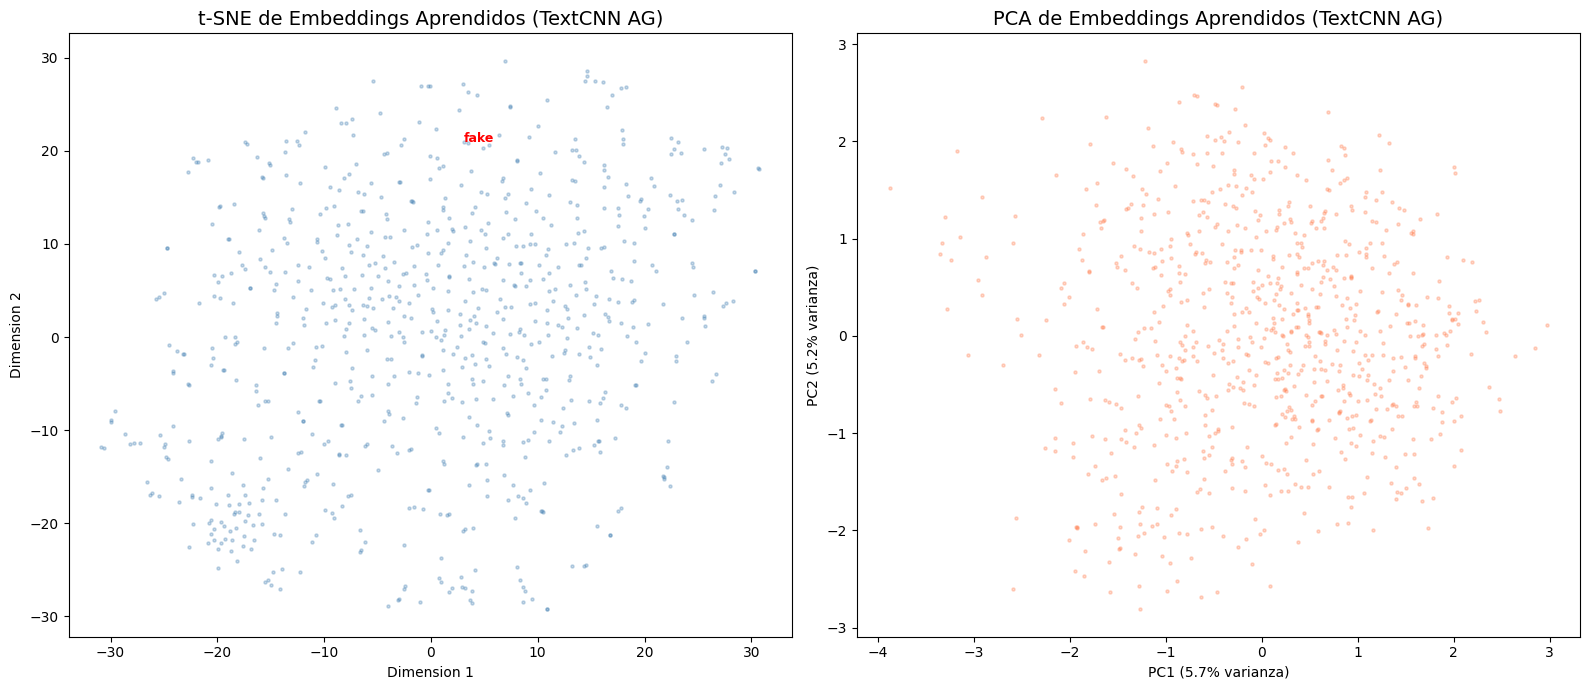

In [12]:
embedding_weights = model.embedding.weight.data.cpu().numpy()

np.random.seed(42)
sample_indices = np.random.choice(range(2, min(VOCAB_SIZE, 5000)), size=800, replace=False)
sample_words   = [idx2word.get(i, f'idx_{i}') for i in sample_indices]
sample_vectors = embedding_weights[sample_indices]

print('Ejecutando t-SNE')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_result = tsne.fit_transform(sample_vectors)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(sample_vectors)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.3, s=5, c='steelblue')
axes[0].set_title('t-SNE de Embeddings Aprendidos (TextCNN AG)', fontsize=14)
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')

palabras_interes = ['trump', 'president', 'election', 'war', 'fake', 'news', 'report', 'official']
for word in palabras_interes:
    if word in word2idx:
        for j, si in enumerate(sample_indices):
            if si == word2idx[word]:
                axes[0].annotate(word, (tsne_result[j, 0], tsne_result[j, 1]),
                                 fontsize=9, fontweight='bold', color='red')
                break

axes[1].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3, s=5, c='coral')
axes[1].set_title('PCA de Embeddings Aprendidos (TextCNN AG)', fontsize=14)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')

plt.tight_layout()
plt.savefig('/kaggle/working/tsne_pca_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
model.eval()
word_importance = np.zeros(VOCAB_SIZE)
word_count      = np.zeros(VOCAB_SIZE)

for batch_idx, (texts, labels) in enumerate(test_loader):
    if batch_idx >= 10:
        break
    texts = texts.to(device)
    texts.requires_grad_(False)

    emb = model.embedding(texts)
    emb.retain_grad()
    x = emb.permute(0, 2, 1)
    conv_outputs = [torch.relu(conv(x)).max(dim=2)[0] for conv in model.convs]
    x = torch.cat(conv_outputs, dim=1)
    x = model.dropout(x)
    output = model.fc(x)

    output.sum().backward()

    grad_magnitude = emb.grad.norm(dim=2).detach().cpu().numpy()
    token_ids = texts.cpu().numpy()

    for i in range(len(token_ids)):
        for j in range(len(token_ids[i])):
            tid = token_ids[i][j]
            if tid > 1:  # excluir PAD y UNK
                word_importance[tid] += grad_magnitude[i][j]
                word_count[tid] += 1

mask = word_count > 0
avg_importance = np.zeros(VOCAB_SIZE)
avg_importance[mask] = word_importance[mask] / word_count[mask]

top_indices = np.argsort(avg_importance)[-20:][::-1]

print('Top 20 palabras mas influyentes para la clasificacion:')
print('-' * 45)
for rank, idx in enumerate(top_indices, 1):
    word = idx2word.get(idx, f'idx_{idx}')
    print(f'{rank:2d}. {word:15s} (importancia: {avg_importance[idx]:.4f})')

Top 20 palabras mas influyentes para la clasificacion:
---------------------------------------------
 1. buchar          (importancia: 5.1782)
 2. prev            (importancia: 5.0876)
 3. bradd           (importancia: 5.0114)
 4. reuters         (importancia: 4.9001)
 5. url             (importancia: 4.3895)
 6. amona           (importancia: 4.3806)
 7. flickr          (importancia: 4.3749)
 8. kinshasa        (importancia: 4.2588)
 9. accorde         (importancia: 4.2240)
10. pinterest       (importancia: 3.9851)
11. ababa           (importancia: 3.9078)
12. wellington      (importancia: 3.9045)
13. trailer         (importancia: 3.8870)
14. est             (importancia: 3.8148)
15. oct             (importancia: 3.7773)
16. yangon          (importancia: 3.7415)
17. dmca            (importancia: 3.7394)
18. nyp             (importancia: 3.7366)
19. khartoum        (importancia: 3.6996)
20. amsterdam       (importancia: 3.6867)


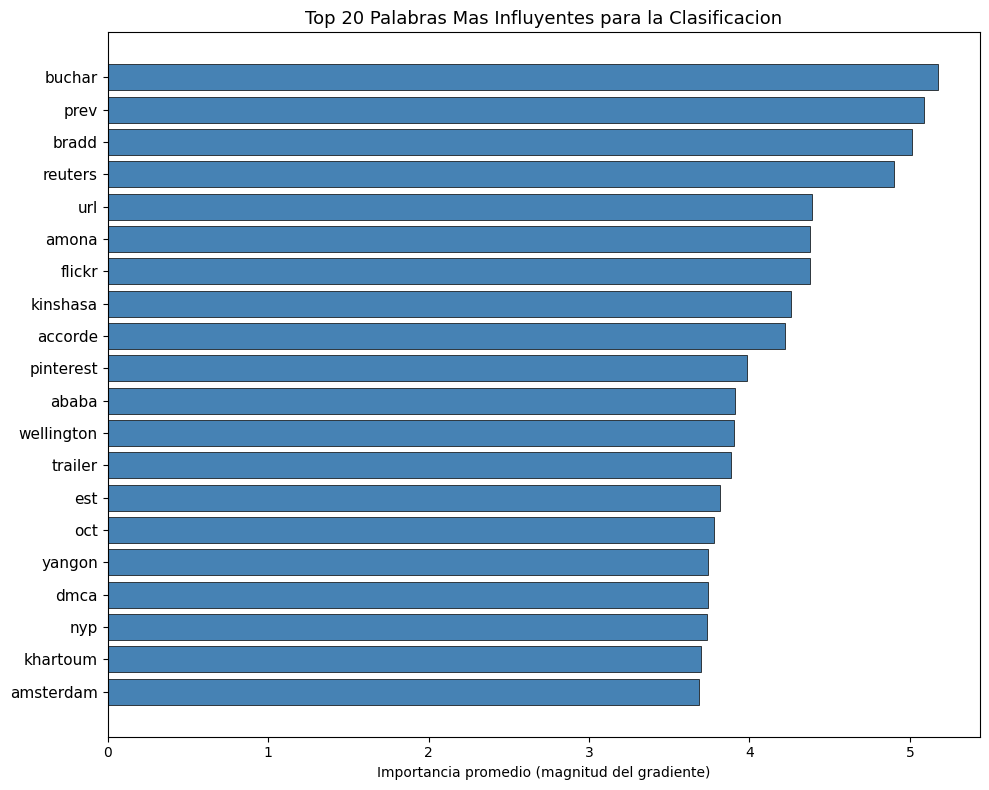

In [14]:
top_words  = [idx2word.get(i, f'idx_{i}') for i in top_indices]
top_scores = [avg_importance[i] for i in top_indices]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top_words)), top_scores[::-1], color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_words)))
ax.set_yticklabels(top_words[::-1], fontsize=11)
ax.set_xlabel('Importancia promedio (magnitud del gradiente)')
ax.set_title('Top 20 Palabras Mas Influyentes para la Clasificacion', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/top_palabras_influyentes.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusiones

**1. Baselines clásicos (TF-IDF + LR/SVM)** alcanzaron un F1 de **0.9717 (LR)** y **0.9630 (SVM)**, demostrando que las señales léxicas superficiales capturadas por TF-IDF (frecuencia de palabras específicas, sin noción de orden ni contexto) son sorprendentemente fuertes para distinguir fake news en este corpus, un baseline difícil de superar incluso con arquitecturas mas sofisticadas.

**2. TextCNN** no logró superar a los baselines en su versión inicial (F1=0.9560 con embeddings random, F1=0.9549 con GloVe en el Reto 4), lo cual confirma que añadir capacidad de modelado semántico (convoluciones + embeddings densos) no garantiza mejor rendimiento si el dataset ya es bien separable con métodos lineales simples sobre features de alta dimensionalidad como TF-IDF.

**3. Los embeddings preentrenados (GloVe)** mejoraron la velocidad de convergencia, pero no siempre el rendimiento final: en el Reto 4 inicial, Random incluso superó levemente a GloVe en algunas métricas, sugiriendo que con suficientes datos de entrenamiento (~50k+ muestras) la red puede aprender embeddings competitivos desde cero. La ventaja real de GloVe se observó en la convergencia (menos épocas necesarias antes de activar early stopping), no en el techo de rendimiento.

**4. El hiperparámetro más impactante** fue el **learning rate**, porque al variarlo entre 1e-5 y 5e-2 (Reto 5), el val_f1 osciló en un rango de 0.143 puntos (0.8131 a 0.9562), mientras que num_filters y dropout solo variaron en rangos de 0.004-0.007. Un learning rate mal elegido no solo da resultados subóptimos, sino que puede impedir la convergencia por completo (divergencia con lr=0.05, estancamiento con lr=1e-5).

**5. El AG (Reto 6)** encontró una arquitectura con F1 de **0.9626**, levemente mejor que la búsqueda manual del Reto 5 (F1=0.9617), una diferencia de +0.0009. El AG fue mejor porque exploró combinaciones conjuntas de los 5 hiperparámetros simultáneamente (embed_dim=100 + filters=256 + kernels=[3,4,5] + dropout=0.5 + lr=0.001), una región del espacio que la búsqueda manual (variando un hiperparámetro a la vez) nunca probó directamente.

**6. La brecha con BERT se debe a** la falta de contextualización dinámica en los embeddings, **específicamente** a que GloVe asigna un vector fijo por palabra sin importar el contexto (la palabra "bank" tiene el mismo vector en "river bank" y "bank account"), mientras que BERT genera representaciones contextuales mediante self-attention, ajustando el significado de cada palabra según toda la oración que la rodea. Además, BERT fue preentrenado en corpus masivos (~3.3 mil millones de palabras) con tareas de modelado de lenguaje bidireccional, capturando estructura gramatical y semántica profunda que TextCNN, limitado a ventanas de convolución de 3-5 palabras, no puede modelar.

**7. La principal limitación de nuestro enfoque es** que el modelo parece aprender metadatos estructurales de la fuente (palabras como `reuters`, `flickr`, nombres de capitales en datelines) en lugar de evaluar el contenido semántico real de la noticia, según mostró el análisis de gradientes. Esto significa que el clasificador probablemente generalizaría mal a noticias de fuentes o formatos distintos a los presentes en WELFake, ya que está aprendiendo un atajo (shortcut learning) basado en convenciones de formato periodístico en vez de razonar sobre la veracidad del contenido.

**8. Si continuáramos este trabajo, exploraríamos** reemplazar GloVe por embeddings contextuales (fine-tuning de un BERT pequeño como DistilBERT) para cerrar la brecha de rendimiento; remover o anonimizar los datelines y metadata de fuente durante el preprocesamiento para forzar al modelo a aprender contenido genuino en vez de atajos estructurales; y ampliar el espacio de búsqueda del AG con genes adicionales (optimizador, batch_size, fine-tuning vs. frozen embeddings) para validar si el techo de ~0.96 de F1 es realmente el límite del dataset o solo de la arquitectura actual.